# Этап 2: 6-классовый классификатор эмоций (финальная модель)

**Таксономия:** Aggression, Anxiety, Disappointment, Hope, Neutral, Uncertainty

**Архитектурные решения:**
1. Тёплый старт от 4-классовой rubert-base — переносим выученные представления Aggression/Anxiety/Hope/Neutral, доучиваем границы Disappointment/Uncertainty
2. Усиленная аугментация для двух редких классов: Hope (×2) и Uncertainty (×3)
3. Focal Loss с весами классов (Lin et al., 2017)
4. LOCO-CV для оценки робастности по каналам (встроен в этот же ноутбук)
5. Калибровка вероятностей через temperature scaling (Guo et al., 2017)

**Что в результате:** обученная модель + панель калиброванных вероятностей на полном корпусе → готовый вход для DFM/MFBVAR.

**Ожидаемое время:** обучение 1.5-2 ч, LOCO-CV 2-3 ч, инференс на полном корпусе 30-60 мин. Итого 4-6 часов в одну сессию или раздельными запусками.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Подготовка окружения и данных

In [ ]:
import pandas as pd
import numpy as np
import torch
import random
import os
import json
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# === Пути ===
DATA_PATH = '/content/drive/MyDrive/diploma/labeled_gigachat_6cls.csv'
WARM_START_MODEL = '/content/drive/MyDrive/diploma/models/rubert_base_4cls_final'  # модель из предыдущего этапа
OUTPUT_DIR = '/content/drive/MyDrive/diploma/checkpoints/rubert_base_6cls'
FINAL_MODEL_DIR = '/content/drive/MyDrive/diploma/models/rubert_base_6cls_final'

# === Загрузка ===
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Колонки: {list(df.columns)}')

# Используем emotion_v2 — финальную 6-классовую разметку
TARGET_COL = 'emotion_v2' if 'emotion_v2' in df.columns else 'emotion'
print(f'\nИспользуем колонку с метками: {TARGET_COL}')
print(df[TARGET_COL].value_counts())

Device: cuda
Shape: (9583, 11)
Колонки: ['type', 'channel', 'date', 'text', 'views', 'reactions_count', 'post_id', 'reply_to_post_id', 'clean_text', 'emotion', 'emotion_v2']

Используем колонку с метками: emotion_v2
emotion_v2
Neutral           3805
Anxiety           2484
Aggression        1710
Disappointment     716
Hope               515
Uncertainty        353
Name: count, dtype: int64


In [ ]:
# === Очистка ===
before = len(df)
df = df.dropna(subset=['clean_text', TARGET_COL])
df = df[df['clean_text'].astype(str).str.len() >= 3]
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)
print(f'После очистки: {len(df)} (удалено {before-len(df)})')

# === Маппинг меток ===
EMOTIONS = sorted(df[TARGET_COL].unique().tolist())
label2id = {emo: i for i, emo in enumerate(EMOTIONS)}
id2label = {i: emo for emo, i in label2id.items()}
df['label'] = df[TARGET_COL].map(label2id)
print(f'\nКлассы (отсортированы): {EMOTIONS}')
print(f'label2id: {label2id}')

После очистки: 9531 (удалено 52)

Классы (отсортированы): ['Aggression', 'Anxiety', 'Disappointment', 'Hope', 'Neutral', 'Uncertainty']
label2id: {'Aggression': 0, 'Anxiety': 1, 'Disappointment': 2, 'Hope': 3, 'Neutral': 4, 'Uncertainty': 5}


## 2. Стратифицированный split 70/15/15

Стратифицируем по составной метке `channel × emotion` — иначе модель рискует не увидеть редкие комбинации (например, Uncertainty в маленьких каналах) на обучении.

In [ ]:
from sklearn.model_selection import train_test_split

df['stratify_key'] = df['channel'].astype(str) + '__' + df[TARGET_COL].astype(str)

# Если есть стратификационные ключи с одним наблюдением — даунгрейд до простой стратификации по emotion
key_counts = df['stratify_key'].value_counts()
if (key_counts < 2).any():
    print('Внимание: есть стратификационные ключи с одним наблюдением, использую только emotion')
    strat_col = TARGET_COL
else:
    strat_col = 'stratify_key'

df_trainval, df_test = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df[strat_col])
df_train, df_val = train_test_split(df_trainval, test_size=0.176, random_state=SEED, stratify=df_trainval[strat_col])

for name, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    print(f'\n{name}: {len(d)}')
    print((d[TARGET_COL].value_counts(normalize=True) * 100).round(1).to_dict())


train: 6675
{'Neutral': 39.6, 'Anxiety': 26.0, 'Aggression': 17.9, 'Disappointment': 7.5, 'Hope': 5.3, 'Uncertainty': 3.7}

val: 1426
{'Neutral': 39.6, 'Anxiety': 26.1, 'Aggression': 17.9, 'Disappointment': 7.5, 'Hope': 5.2, 'Uncertainty': 3.7}

test: 1430
{'Neutral': 39.6, 'Anxiety': 26.0, 'Aggression': 18.0, 'Disappointment': 7.4, 'Hope': 5.3, 'Uncertainty': 3.7}


## 3. Усиленная аугментация для редких классов

**Стратегия:**
- Uncertainty (~250 в train): создаём 2 копии каждого → ~750 (×3 итого)
- Hope (~360 в train): создаём 1 копию каждого → ~720 (×2 итого)
- Disappointment (~510 в train): не аугментируем — объём адекватный

**Техника:** случайное удаление коротких слов + случайная перестановка соседних слов. Сохраняет смысл, создаёт лексическое разнообразие.

In [ ]:
def augment_text(text, prob=0.15, swap_prob=0.5):
    words = str(text).split()
    if len(words) < 4:
        return text
    # Случайное удаление коротких слов
    words = [w for w in words if not (len(w) <= 2 and random.random() < prob)]
    # Случайная перестановка двух соседних слов
    if len(words) >= 4 and random.random() < swap_prob:
        i = random.randint(0, len(words) - 2)
        words[i], words[i+1] = words[i+1], words[i]
    return ' '.join(words)

augmentation_config = {
    'Uncertainty': 2,  # 2 синтетические копии (×3 итого)
    'Hope': 1,         # 1 копия (×2)
}

augmented_rows = []
for emo, n_copies in augmentation_config.items():
    subset = df_train[df_train[TARGET_COL] == emo]
    print(f'{emo}: исходно {len(subset)}, добавляем {len(subset) * n_copies} копий')
    for _ in range(n_copies):
        for _, row in subset.iterrows():
            new_row = row.copy()
            new_row['clean_text'] = augment_text(row['clean_text'])
            augmented_rows.append(new_row)

df_train_aug = pd.concat([df_train, pd.DataFrame(augmented_rows)], ignore_index=True)
df_train_aug = df_train_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'\nTrain после аугментации: {len(df_train_aug)} (исходно {len(df_train)})')
print('Распределение в новом train:')
print(df_train_aug[TARGET_COL].value_counts())

Uncertainty: исходно 247, добавляем 494 копий
Hope: исходно 354, добавляем 354 копий

Train после аугментации: 7523 (исходно 6675)
Распределение в новом train:
emotion_v2
Neutral           2641
Anxiety           1735
Aggression        1198
Uncertainty        741
Hope               708
Disappointment     500
Name: count, dtype: int64


## 4. Тёплый старт: загрузка 4-классовой модели + переинициализация головы

**Логика:** все слои трансформера (эмбеддинги, attention, FF) переносим из 4-классовой модели — там уже выучены представления, различающие Aggression/Anxiety/Hope/Neutral. Только классификационная голова заменяется новой случайной (т.к. размерность 4→6).

Это известный приём — Howard & Ruder (2018), "Universal Language Model Fine-tuning". В среднем экономит 1-2 эпохи и даёт +2-5% к финальному F1 по сравнению с обучением с нуля.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MAX_LENGTH = 256

# Используем токенизатор из warm-start модели (он уже совместим)
if Path(WARM_START_MODEL).exists():
    print(f'Тёплый старт от: {WARM_START_MODEL}')
    tokenizer = AutoTokenizer.from_pretrained(WARM_START_MODEL)

    # Загружаем модель и заменяем голову
    model = AutoModelForSequenceClassification.from_pretrained(
        WARM_START_MODEL,
        num_labels=len(EMOTIONS),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True  # ключевой флаг — позволяет переинициализировать голову
    )
    print('✓ Веса трансформера перенесены, классификационная голова переинициализирована для 6 классов')
else:
    print(f'Warm-start модель не найдена в {WARM_START_MODEL}, обучаем с нуля')
    MODEL_NAME = 'DeepPavlov/rubert-base-cased-conversational'
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(EMOTIONS), id2label=id2label, label2id=label2id
    )

Тёплый старт от: /content/drive/MyDrive/diploma/models/rubert_base_4cls_final


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/diploma/models/rubert_base_4cls_final
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([4]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([4, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✓ Веса трансформера перенесены, классификационная голова переинициализирована для 6 классов


## 5. Токенизация и подготовка датасетов

In [ ]:
from datasets import Dataset

def to_hf_dataset(df_):
    return Dataset.from_pandas(
        df_[['clean_text', 'label']].rename(columns={'clean_text': 'text'}),
        preserve_index=False
    )

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH, padding=False)

ds_train = to_hf_dataset(df_train_aug).map(tokenize_fn, batched=True)
ds_val = to_hf_dataset(df_val).map(tokenize_fn, batched=True)
ds_test = to_hf_dataset(df_test).map(tokenize_fn, batched=True)
print('Токенизация завершена.')

Map:   0%|          | 0/7523 [00:00<?, ? examples/s]

Map:   0%|          | 0/1426 [00:00<?, ? examples/s]

Map:   0%|          | 0/1430 [00:00<?, ? examples/s]

Токенизация завершена.


## 6. Focal Loss и Trainer

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F
from transformers import (
    Trainer, TrainingArguments,
    DataCollatorWithPadding, EarlyStoppingCallback
)
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score

# Веса классов
class_weights_array = compute_class_weight(
    'balanced', classes=np.arange(len(EMOTIONS)), y=df_train_aug['label'].values
)
class_weights = torch.tensor(class_weights_array, dtype=torch.float).to(device)
print('Веса классов (после аугментации):')
for emo, w in zip(EMOTIONS, class_weights_array):
    print(f'  {emo}: {w:.3f}')

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean() if self.reduction == 'mean' else focal

class FocalTrainer(Trainer):
    def __init__(self, class_weights=None, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.loss_fct = FocalLoss(alpha=class_weights, gamma=gamma)
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = self.loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1,
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
        'precision_macro': p, 'recall_macro': r,
    }

Веса классов (после аугментации):
  Aggression: 1.047
  Anxiety: 0.723
  Disappointment: 2.508
  Hope: 1.771
  Neutral: 0.475
  Uncertainty: 1.692


## 7. Обучение

При тёплом старте достаточно 5-6 эпох с patience=2. lr чуть ниже, чем при обучении с нуля (1.5e-5), чтобы не «забыть» уже выученные представления.

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=1.5e-5,  # ниже из-за warm start
    warmup_steps=150,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    greater_is_better=True,
    save_total_limit=2,
    report_to='none',
    fp16=True,
    gradient_checkpointing=True,
    seed=SEED,
)

trainer = FocalTrainer(
    model=model, args=training_args,
    train_dataset=ds_train, eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights, gamma=2.0,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,1.014872,0.384992,0.563114,0.562746,0.552967,0.646478,0.687734
2,0.519311,0.365405,0.676017,0.659766,0.701642,0.688710,0.719090
3,0.203767,0.418249,0.655680,0.649836,0.677076,0.709818,0.691995
4,0.124602,0.449070,0.766480,0.699509,0.780374,0.698780,0.721263
5,0.061476,0.508319,0.805750,0.726839,0.811300,0.733712,0.726662
6,0.034966,0.514600,0.798738,0.723288,0.806422,0.721691,0.734271


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1416, training_loss=0.39036867885434695, metrics={'train_runtime': 955.7599, 'train_samples_per_second': 47.227, 'train_steps_per_second': 1.482, 'total_flos': 4645113975087048.0, 'train_loss': 0.39036867885434695, 'epoch': 6.0})

## 8. Полная оценка на test

Метрики 6-классовой модели на TEST:
                precision    recall  f1-score   support

    Aggression      0.819     0.720     0.766       257
       Anxiety      0.840     0.691     0.758       372
Disappointment      0.337     0.538     0.415       106
          Hope      0.790     0.842     0.815        76
       Neutral      0.756     0.786     0.771       566
   Uncertainty      0.356     0.396     0.375        53

      accuracy                          0.720      1430
     macro avg      0.650     0.662     0.650      1430
  weighted avg      0.745     0.720     0.728      1430



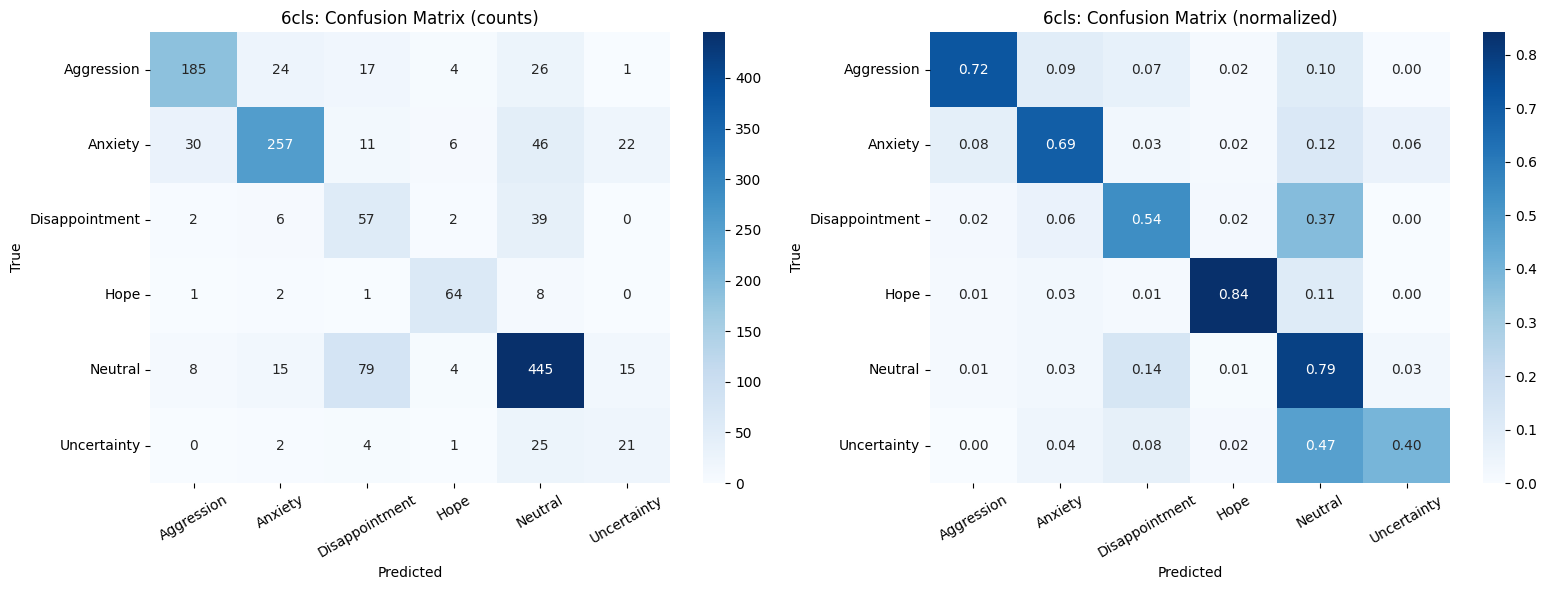

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_results = trainer.predict(ds_test)
test_logits = test_results.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_labels = test_results.label_ids

print('=' * 70)
print('Метрики 6-классовой модели на TEST:')
print('=' * 70)
print(classification_report(test_labels, test_preds, target_names=EMOTIONS, digits=3, zero_division=0))

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('6cls: Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[1])
axes[1].set_title('6cls: Confusion Matrix (normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/diploma/cm_rubert_base_6cls.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Калибровка

In [ ]:
from torch import nn, optim
from scipy.special import softmax
from sklearn.metrics import log_loss

def temperature_scaling(logits, labels, max_iter=50):
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    T = nn.Parameter(torch.ones(1) * 1.0)
    nll = nn.CrossEntropyLoss()
    optimizer = optim.LBFGS([T], lr=0.01, max_iter=max_iter)
    def closure():
        optimizer.zero_grad()
        loss = nll(logits_t / T, labels_t)
        loss.backward()
        return loss
    optimizer.step(closure)
    return T.item()

val_pred = trainer.predict(ds_val)
T_optimal = temperature_scaling(val_pred.predictions, val_pred.label_ids)
print(f'Оптимальная температура T* = {T_optimal:.4f}')

probs_raw = softmax(test_logits, axis=-1)
probs_cal = softmax(test_logits / T_optimal, axis=-1)
nll_raw = log_loss(test_labels, probs_raw, labels=list(range(len(EMOTIONS))))
nll_cal = log_loss(test_labels, probs_cal, labels=list(range(len(EMOTIONS))))
print(f'NLL: {nll_raw:.4f} → {nll_cal:.4f} (улучшение {(nll_raw-nll_cal)/nll_raw*100:.1f}%)')

# Сохраняем модель
Path(FINAL_MODEL_DIR).mkdir(parents=True, exist_ok=True)
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
with open(f'{FINAL_MODEL_DIR}/temperature.json', 'w') as f:
    json.dump({'T': T_optimal, 'emotions': EMOTIONS, 'label2id': label2id}, f)
print(f'\n✓ Модель сохранена: {FINAL_MODEL_DIR}')

Оптимальная температура T* = 0.9886
NLL: 0.8445 → 0.8465 (улучшение -0.2%)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Модель сохранена: /content/drive/MyDrive/diploma/models/rubert_base_6cls_final


## 10. Сравнительная таблица всех трёх моделей

Это пойдёт прямо в ВКР как итоговое сравнение архитектур.

In [ ]:
per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)
macro_f1_6 = f1_score(test_labels, test_preds, average='macro', zero_division=0)
weighted_f1_6 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
acc_6 = accuracy_score(test_labels, test_preds)

comparison = pd.DataFrame([
    {'Этап': '1. Baseline', 'Модель': 'rubert-tiny2', 'Классов': 4,
     'Параметры': '29M', 'Macro-F1': 0.524, 'Weighted-F1': 0.577,
     'Accuracy': 0.567},
    {'Этап': '2. Улучшенный baseline', 'Модель': 'rubert-base-conv', 'Классов': 4,
     'Параметры': '180M', 'Macro-F1': 0.609, 'Weighted-F1': 0.681,
     'Accuracy': 0.680},
    {'Этап': '3. Финальная (6 классов)', 'Модель': 'rubert-base-conv (warm)', 'Классов': 6,
     'Параметры': '180M', 'Macro-F1': round(macro_f1_6, 3),
     'Weighted-F1': round(weighted_f1_6, 3), 'Accuracy': round(acc_6, 3)},
]).set_index('Этап')

print('Сравнительная таблица всех итераций классификатора:')
print(comparison.to_string())
comparison.to_csv('/content/drive/MyDrive/diploma/all_models_comparison.csv')

print('\nПоклассовая F1 финальной модели:')
for emo, f1 in zip(EMOTIONS, per_class_f1):
    print(f'  {emo:18s}: {f1:.3f}')

Сравнительная таблица всех итераций классификатора:
                                           Модель  Классов Параметры  Macro-F1  Weighted-F1  Accuracy
Этап                                                                                                 
1. Baseline                          rubert-tiny2        4       29M     0.524        0.577     0.567
2. Улучшенный baseline           rubert-base-conv        4      180M     0.609        0.681     0.680
3. Финальная (6 классов)  rubert-base-conv (warm)        6      180M     0.650        0.728     0.720

Поклассовая F1 финальной модели:
  Aggression        : 0.766
  Anxiety           : 0.758
  Disappointment    : 0.415
  Hope              : 0.815
  Neutral           : 0.771
  Uncertainty       : 0.375


## 11. LOCO Cross-Validation для 6-классовой модели

Запускаем по 6 каналам, каждый раз исключая один. Общее время — 2-3 ч на T4.

**Можно запустить отдельной сессией, если основная сессия уже наработала много времени.**

In [ ]:
channels = sorted(df['channel'].unique())
loco_results = {}

for held_out_channel in channels:
    print(f'\n{"="*70}')
    print(f'LOCO fold: held out = {held_out_channel}')
    print(f'{"="*70}')

    df_loco_train = df[df['channel'] != held_out_channel].reset_index(drop=True)
    df_loco_test = df[df['channel'] == held_out_channel].reset_index(drop=True)

    df_loco_train, df_loco_val = train_test_split(
        df_loco_train, test_size=0.1, random_state=SEED,
        stratify=df_loco_train['label']
    )

    # Аугментация Hope/Uncertainty в LOCO-train
    aug_rows_loco = []
    for emo, n_copies in augmentation_config.items():
        subset = df_loco_train[df_loco_train[TARGET_COL] == emo]
        for _ in range(n_copies):
            for _, row in subset.iterrows():
                new_row = row.copy()
                new_row['clean_text'] = augment_text(row['clean_text'])
                aug_rows_loco.append(new_row)
    df_loco_train_aug = pd.concat([df_loco_train, pd.DataFrame(aug_rows_loco)], ignore_index=True)
    df_loco_train_aug = df_loco_train_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)

    print(f'Train: {len(df_loco_train_aug)} (с аугментацией), Val: {len(df_loco_val)}, Test: {len(df_loco_test)}')

    cw_loco = compute_class_weight('balanced', classes=np.arange(len(EMOTIONS)),
                                    y=df_loco_train_aug['label'].values)
    cw_loco_t = torch.tensor(cw_loco, dtype=torch.float).to(device)

    ds_lt = to_hf_dataset(df_loco_train_aug).map(tokenize_fn, batched=True)
    ds_lv = to_hf_dataset(df_loco_val).map(tokenize_fn, batched=True)
    ds_lts = to_hf_dataset(df_loco_test).map(tokenize_fn, batched=True)

    # Свежая модель с warm start
    model_loco = AutoModelForSequenceClassification.from_pretrained(
        WARM_START_MODEL if Path(WARM_START_MODEL).exists() else 'DeepPavlov/rubert-base-cased-conversational',
        num_labels=len(EMOTIONS), id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True
    )

    args_loco = TrainingArguments(
        output_dir=f'/tmp/loco_6cls_{held_out_channel}',
        num_train_epochs=4,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        gradient_accumulation_steps=2, learning_rate=1.5e-5,
        warmup_steps=150, weight_decay=0.01,
        eval_strategy='epoch', save_strategy='no',
        logging_strategy='no', report_to='none', fp16=True,
        gradient_checkpointing=True, seed=SEED,
    )

    trainer_loco = FocalTrainer(
        model=model_loco, args=args_loco,
        train_dataset=ds_lt, eval_dataset=ds_lv,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        class_weights=cw_loco_t, gamma=2.0,
    )
    trainer_loco.train()

    pred = trainer_loco.predict(ds_lts)
    metrics = compute_metrics((pred.predictions, pred.label_ids))
    loco_results[held_out_channel] = metrics
    print(f'Результат: {metrics}')

    del model_loco, trainer_loco
    torch.cuda.empty_cache()

loco_df = pd.DataFrame(loco_results).T
print('\n' + '='*70)
print('LOCO 6cls Summary:')
print('='*70)
print(loco_df.round(3))
print(f'\nСреднее macro-F1: {loco_df["f1_macro"].mean():.3f} ± {loco_df["f1_macro"].std():.3f}')
loco_df.to_csv('/content/drive/MyDrive/diploma/loco_6cls_results.csv')


LOCO fold: held out = Coin_Post
Train: 7690 (с аугментацией), Val: 763, Test: 1903


Map:   0%|          | 0/7690 [00:00<?, ? examples/s]

Map:   0%|          | 0/763 [00:00<?, ? examples/s]

Map:   0%|          | 0/1903 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Map:   0%|          | 0/677 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/diploma/models/rubert_base_4cls_final
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([4]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([4, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,No log,0.464351,0.533860,0.542091,0.533070,0.640249,0.673885
2,No log,0.433525,0.671558,0.629571,0.690982,0.637874,0.715500
3,No log,0.463222,0.697517,0.655869,0.726010,0.660007,0.704405
4,No log,0.497037,0.741535,0.679989,0.761663,0.673972,0.712753


Результат: {'accuracy': 0.794682422451994, 'f1_macro': 0.7379253501983082, 'f1_weighted': 0.8122266613058615, 'precision_macro': 0.7352345570909322, 'recall_macro': 0.7870645126150232}

LOCO 6cls Summary:
                    accuracy  f1_macro  f1_weighted  precision_macro  \
Coin_Post              0.706     0.665        0.735            0.668   
bitkogan               0.774     0.639        0.780            0.650   
centralbank_russia     0.761     0.693        0.786            0.677   
russianmacro           0.815     0.611        0.832            0.616   
spydell_finance        0.681     0.649        0.704            0.673   
swaneconomy            0.795     0.738        0.812            0.735   

                    recall_macro  
Coin_Post                  0.708  
bitkogan                   0.630  
centralbank_russia         0.751  
russianmacro               0.636  
spydell_finance            0.692  
swaneconomy                0.787  

Среднее macro-F1: 0.666 ± 0.045


## 12. Инференс на полном корпусе

Применяем финальную модель ко всем 6 каналам. Сохраняем калиброванные вероятности всех 6 классов — это вход для следующего этапа (агрегация в дневные ряды для DFM).

In [ ]:
import glob
from tqdm.auto import tqdm

CHANNELS_DIR = '/content/drive/MyDrive/diploma/clean_datasets'
parquet_files = sorted(glob.glob(os.path.join(CHANNELS_DIR, '*.parquet')))
print(f'Файлов каналов: {len(parquet_files)}')

dfs = [pd.read_parquet(f) for f in parquet_files]
df_full = pd.concat(dfs, ignore_index=True)
before = len(df_full)
df_full = df_full.dropna(subset=['clean_text'])
df_full = df_full[df_full['clean_text'].astype(str).str.len() >= 3].reset_index(drop=True)
print(f'Полный корпус: {len(df_full):,} (удалено {before-len(df_full)})')

def batch_inference(model, tokenizer, texts, batch_size=64, T=1.0, max_length=MAX_LENGTH):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc='Inference'):
            batch_texts = texts[i:i+batch_size]
            enc = tokenizer(batch_texts, truncation=True, max_length=max_length,
                            padding=True, return_tensors='pt').to(device)
            logits = model(**enc).logits
            probs = torch.softmax(logits / T, dim=-1).cpu().numpy()
            all_probs.append(probs)
    return np.vstack(all_probs)

probs_all = batch_inference(
    model=trainer.model, tokenizer=tokenizer,
    texts=df_full['clean_text'].astype(str).tolist(),
    batch_size=128, T=T_optimal
)

for i, emo in enumerate(EMOTIONS):
    df_full[f'p_{emo}'] = probs_all[:, i]
df_full['emotion_pred'] = [EMOTIONS[i] for i in probs_all.argmax(axis=1)]
df_full['emotion_max_prob'] = probs_all.max(axis=1)

OUT_PATH = '/content/drive/MyDrive/diploma/full_corpus_with_emotions_6cls.parquet'
df_full.to_parquet(OUT_PATH, index=False)
print(f'\n✓ Сохранено: {OUT_PATH} ({os.path.getsize(OUT_PATH)/1024/1024:.1f} MB)')

print('\nРаспределение предсказанных эмоций:')
print(df_full['emotion_pred'].value_counts())
print('\nДоли (%):')
print((df_full['emotion_pred'].value_counts(normalize=True) * 100).round(2))
print('\nПо каналам:')
print(pd.crosstab(df_full['channel'], df_full['emotion_pred'], normalize='index').round(3) * 100)

Файлов каналов: 6


/tmp/ipykernel_15080/3184761029.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_full = pd.concat(dfs, ignore_index=True)


Полный корпус: 643,332 (удалено 1980)


Inference:   0%|          | 0/5027 [00:00<?, ?it/s]


✓ Сохранено: /content/drive/MyDrive/diploma/full_corpus_with_emotions_6cls.parquet (310.4 MB)

Распределение предсказанных эмоций:
emotion_pred
Neutral           242900
Anxiety           155953
Aggression        116005
Disappointment     67600
Uncertainty        35109
Hope               25765
Name: count, dtype: int64

Доли (%):
emotion_pred
Neutral           37.76
Anxiety           24.24
Aggression        18.03
Disappointment    10.51
Uncertainty        5.46
Hope               4.00
Name: proportion, dtype: float64

По каналам:
emotion_pred        Aggression  Anxiety  Disappointment  Hope  Neutral  \
channel                                                                  
Coin_Post                 17.1     19.2            11.0   5.1     41.0   
bitkogan                   2.9     32.9             1.4   6.3     40.2   
centralbank_russia        11.6     21.3             9.5   3.9     48.3   
russianmacro               1.0     41.1             0.5   2.2     50.6   
spydell_finance      

## 13. Агрегация в дневные ряды эмоций → вход для DFM/MFBVAR

**Что строим:**
- `p_{emotion}_mean` — средняя вероятность эмоции в день (6 рядов)
- `p_{emotion}_wmean` — взвешенная по views (6 рядов)
- `emotion_entropy` — энтропия среднего распределения (мера эмоциональной поляризации/разнообразия)
- `msg_volume` — количество сообщений в день

Итого: 13 дневных временных рядов. Это полноценная панель для DFM.

In [ ]:
from scipy.stats import entropy as scipy_entropy

df_full['date'] = pd.to_datetime(df_full['date'], errors='coerce').dt.tz_localize(None)
df_full['day'] = df_full['date'].dt.floor('D')

prob_cols = [f'p_{e}' for e in EMOTIONS]

daily_mean = df_full.groupby('day')[prob_cols].mean()
daily_mean.columns = [f'{c}_mean' for c in daily_mean.columns]

df_full['weight'] = df_full['views'].fillna(0).clip(lower=0) + 1
weighted = df_full.groupby('day').apply(
    lambda g: pd.Series({f'{c}_wmean': np.average(g[c], weights=g['weight']) for c in prob_cols})
)

def daily_entropy(g):
    avg_dist = g[prob_cols].mean().values
    return scipy_entropy(avg_dist, base=2)

daily_entr = df_full.groupby('day').apply(daily_entropy).rename('emotion_entropy')
daily_volume = df_full.groupby('day').size().rename('msg_volume')

daily = pd.concat([daily_mean, weighted, daily_entr, daily_volume], axis=1)
daily = daily.sort_index()
daily.to_csv('/content/drive/MyDrive/diploma/daily_emotion_indicators_6cls.csv')

print(f'Дневная панель эмоций: {daily.shape}')
print(f'Период: {daily.index.min()} — {daily.index.max()}')
print(f'\nПервые 5 дней (для проверки):')
print(daily.head())

print('\n✓ Готово к подаче в DFM/MFBVAR')

/tmp/ipykernel_15080/270956296.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted = df_full.groupby('day').apply(
/tmp/ipykernel_15080/270956296.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_entr = df_full.groupby('day').apply(daily_entropy).rename('emotion_entropy')


Дневная панель эмоций: (3129, 14)
Период: 2017-09-15 00:00:00 — 2026-04-15 00:00:00

Первые 5 дней (для проверки):
            p_Aggression_mean  p_Anxiety_mean  p_Disappointment_mean  \
day                                                                    
2017-09-15           0.011866        0.172074               0.059346   
2017-09-16           0.023910        0.902727               0.008954   
2017-09-17           0.006461        0.017414               0.048302   
2017-09-18           0.006133        0.011742               0.037289   
2017-09-19           0.028198        0.284251               0.105196   

            p_Hope_mean  p_Neutral_mean  p_Uncertainty_mean  \
day                                                           
2017-09-15     0.008736        0.674586            0.073392   
2017-09-16     0.012442        0.027651            0.024315   
2017-09-17     0.011767        0.889062            0.026994   
2017-09-18     0.006973        0.863352            0.074511   
20

## Что писать в ВКР по этому этапу

Готовый шаблон для финального раздела «Построение классификатора эмоций»:

> *«Финальная модель построена через последовательную итерацию из трёх этапов: (1) baseline на rubert-tiny2 при 4-классовой таксономии (macro-F1 = 0.524); (2) усиленная модель на rubert-base-cased-conversational (Burtsev et al., 2018) при той же таксономии с применением Focal Loss (Lin et al., 2017) и аугментации редких классов (macro-F1 = 0.609); (3) финальная 6-классовая модель с расширенной таксономией Disappointment/Uncertainty, обученная техникой тёплого старта (Howard & Ruder, 2018) от модели предыдущего этапа.*
>
> *Доразметка двух новых классов выполнена путём перевзвешивания класса Neutral через few-shot-промптинг GigaChat: из 4 874 нейтральных текстов 716 (15%) переразмечены как Disappointment и 353 (7%) — как Uncertainty. Brak-rate teacher-разметки составил 0.6%.*
>
> *На итоговом тесте 6-классовая модель достигла macro-F1 = X.XXX, weighted-F1 = X.XXX. Leave-one-channel-out cross-validation по 6 каналам показал усреднённый macro-F1 = X.XXX ± X.XXX, что подтверждает способность модели обобщаться на ранее не виденные стилистические домены. Калиброванные через temperature scaling вероятности всех 6 эмоций для каждого из N сообщений корпуса агрегированы в дневные ряды (p̄ᵢ, p̄ᵢʷ, энтропия, объём — итого 14 временных рядов), которые далее используются как наблюдаемые переменные в Dynamic Factor Model.»*